# **III. Sentiment analysis**

We first load cleaned tweets and headlines.

In [ ]:
import pandas as pd
dfTweets = pd.read_csv(f'data/output/cleaned_tweets.csv')
dfHL = pd.read_csv("data/output/HL_all_cleaned.csv", sep=";")

### **III.A. Influential Tweets**

We then define which tweets are influential. A tweet is defined as influential if any of its metrics (comment_num, retweet_num, like_num) exceed the 99th percentile for those metrics. We distinguish influential tweets from non-influential tweets (SHAO et al., 2025).

In [ ]:
com99th, rt99th, like99th = dfTweets['comment_num'].quantile(0.99), dfTweets['retweet_num'].quantile(0.99), dfTweets['like_num'].quantile(0.99)
print(f"99th comments: {com99th}\n99th RT: {rt99th}\n99th like: {like99th}")

dfTweets['influential'] = (
    (dfTweets['comment_num'] > com99th) |
    (dfTweets['retweet_num'] > like99th) |
    (dfTweets['like_num'] > like99th)
)

99th comments: 6.0
99th RT: 11.0
99th like: 45.0


### **III.B. Sentiment analysis**

We then proceed with various types of sentiment analysis: VADER, TextBlob, Bag of Words, RoBERTa and FinBERT. 

#### **III.B.1. VADER**

[VADER](https://github.com/cjhutto/vaderSentiment) sentiment analysis. Instead of using the compound score, we substract the negative sentiment scores from positive sentiment scores as our final variable (SHAO et al., 2025).

We compute VADER scores for both tweets and headlines.

In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

tweets = dfTweets["body"].fillna('').astype(str)
headlines = dfHL["headline"].fillna('').astype(str)
analyzer = SentimentIntensityAnalyzer()

vader_score = []
for tweet in tweets:
    vs = analyzer.polarity_scores(tweet)
    vader_score.append(vs['pos'] - vs['neg'])

dfTweets['VADER'] = vader_score

vader_H_score = []
for headline in headlines:
    vs = analyzer.polarity_scores(headline)
    vader_H_score.append(vs['pos'] - vs['neg'])

dfHL['VADER'] = vader_H_score

#### **III.2.2. Bag of Words (BoW)**

$$\text{BoW score}=
\begin{cases}
\frac{\text{count}_p-\text{count}_n}{\text{count}_p+\text{count}_n}, & \text{if count}_p + \text{count}_n > 0 ;\\
0, & \text{otherwise} ;
\end{cases}
$$

Where $\text{count}_p$ and $\text{count}_n$ denote the count of positive and negative words, respectively.

NLTK initial vocabulary is limited: we add some positive and negative financial jargon to its vocabulary, but the NLKT opinion lexicon still yields discrete sentiment scores (-1, 0, 1) for most tweets due to its limited coverage.

In [ ]:
from nltk.corpus import opinion_lexicon
from nltk.tokenize import word_tokenize
import nltk

# Needed ressources
nltk.download('opinion_lexicon')
nltk.download('punkt')
nltk.download('punkt_tab')

pos_words = set(opinion_lexicon.positive()) # positive words
neg_words = set(opinion_lexicon.negative())# negative words

# We add some financial jargon that wasn't in the opinion lexicon
fin_pos = {"surge", "profit", "uptrend", "beat", "buy", "bull", "skyrocket"}
fin_neg = {"plunge", "selloff", "underperform", "downtrend", "sell", "bear", "bankruptcy", "bankrupt"}

pos_words.update(fin_pos)
neg_words.update(fin_neg)


BoW_scores = []
for tweet in tweets:
    tokens = word_tokenize(tweet.lower())
    count_p = sum(1 for token in tokens if token in pos_words)
    count_n = sum(1 for token in tokens if token in neg_words)

    # BoW score formula
    if count_p + count_n > 0: BoW_score = (count_p - count_n) / (count_p + count_n)
    else: BoW_score = 0.0
    BoW_scores.append(BoW_score)

dfTweets['BoW'] = BoW_scores


BoW_H_scores = []
for headline in headlines:
    Htokens = word_tokenize(headline.lower())
    count_p = sum(1 for Htoken in Htokens if Htoken in pos_words)
    count_n = sum(1 for Htoken in Htokens if Htoken in neg_words)

    # BoW score formula
    if count_p + count_n > 0: BoW_H_score = (count_p - count_n) / (count_p + count_n)
    else: BoW_H_score = 0.0
    BoW_H_scores.append(BoW_H_score)

dfHL['BoW'] = BoW_H_scores

[nltk_data] Downloading package opinion_lexicon to
[nltk_data]     /Users/eyquem/nltk_data...
[nltk_data]   Package opinion_lexicon is already up-to-date!
[nltk_data] Downloading package punkt to /Users/eyquem/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/eyquem/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


#### **III.B.3. TextBlob (TB)**

We use TextBlob for further sentiment analysis. TB alread provides a sentiment polarity score in the range [-1, 1].

In [ ]:
from textblob import TextBlob

TB_scores = []
for tweet in tweets:
    TB = TextBlob(tweet)
    TB_scores.append(TB.sentiment.polarity)
dfTweets['TBlob'] = TB_scores
dfTweets.to_csv("data/output/tweets_preRoBERTa.csv")

TB_H_scores = []
for headline in headlines:
    TB_H = TextBlob(headline)
    TB_H_scores.append(TB_H.sentiment.polarity)
dfHL['TBlob'] = TB_H_scores

#### **III.B.4. RoBERTa**

We use a [pre-trained RoBERTa model fine-tuned for sentiment analysis](https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest).

Sentiment of the model: 0: = Negative; 1 = Neutral; 2 = Positive

We access the model via HuggingFace.

In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer, AutoConfig
from scipy.special import softmax
from tqdm import tqdm

# Model config
MODEL = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
config = AutoConfig.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

def preprocess(text):
    if not isinstance(text, str):
        return ""
    new_text = []
    for t in text.split(" "):
        new_text.append(t)
    return " ".join(new_text)

def get_RoBERTa_score(text):
    try:
        text = preprocess(text)
        encoded_input = tokenizer(text, return_tensors='pt', truncation=True, max_length=512)
        output = model(**encoded_input)
        scores = output[0][0].detach().numpy()
        scores = softmax(scores)
        
        score = scores[2] - scores[0] # positive - negative
        return score
    except:
        return 0.0

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 32508.97it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
dfTweets = pd.read_csv("data/output/tweets_preRoBERTa.csv")
begin, to = 0, 100
tqdm.pandas(desc="RoBERTa sentiment")
dfTweets['RoBERTa'] = dfTweets['body'].fillna('').astype(str).iloc[begin:to].progress_apply(get_RoBERTa_score)
dfTweets.to_csv(f"data/output/RoBERTa_{begin}_to_{to}.csv", index=True)

RoBERTa sentiment: 100%|██████████| 100/100 [00:03<00:00, 30.03it/s]


In [ ]:
tqdm.pandas(desc="RoBERTa sentiment")
dfHL['RoBERTa'] = dfHL['headline'].fillna('').astype(str).progress_apply(get_RoBERTa_score)
dfHL.to_csv(f"data/output/HL_sentiment.csv", index=True)

RoBERTa sentiment:   0%|          | 0/11532 [00:00<?, ?it/s]

RoBERTa sentiment: 100%|██████████| 11532/11532 [06:12<00:00, 30.94it/s]


#### **III.B.5. FinBERTa**

We use FinBERT, a pre-trained NLP model, to analyse the sentiment of 3M tweets. FinBERT is built by further training on financial data of the BERT language model developed by Google. 


We load the model from ProsusAI/finbert on Hugging Face.

In [ ]:
from transformers import pipeline
import torch

classifier = pipeline(
    "text-classification", 
    model="ProsusAI/finbert", 
    device=torch.device("mps"), # Apple Silicon M2 GPU
    #dtype=torch.float16, 
    batch_size=512 # 16go RAM
)

In [ ]:
from tqdm import tqdm

begin = 0
to = 100

df_slice = df.iloc[begin:to].copy()
tweets = df_slice['body'].fillna("").tolist()

results = []

for tweet in tqdm(tweets, desc="FinBERT"):
    out = classifier(tweet)[0]  
    results.append({
        'label': out['label'],
        'score': out['score']
    })

df_results = pd.DataFrame(results, index=df_slice.index)  
df_slice = pd.concat([df_slice, df_results], axis=1)

df_slice.to_csv(f"data/output/finBERT_{begin}_to_{to}.csv", index=True)

### **III.C. Daily weighted sentiment and influence averages**

The paper uses follower-weighted average and tweet-influential-weighted average. Without follower count, we experiment with a simple average, an influential-weighted average and a log-weighted average taking into account comments, likes and retweets. For non-trading days, we assign tweets and headlines to the first following trading day, for which we calculate the "daily" average.

$$\text{General Avg}_z=\frac{1}{T}\sum^T_{i=1}S_{i,z}$$

$$\text{Tweet Influential Weight}_z=\frac{\sum^T_{i=1}(D_i+1)\times S_{i,z}}{\sum^T_{i=1}(D_i+1)}$$

$$\text{Tweet Log-Weighted}_z=\frac{\sum^T_{i=1}\log(1+\text{comments}_i+\text{RT}_i+\text{likes}_i)\times S_{i,z}}{\sum^T_{i=1}\log(1+\text{comments}_i+\text{RT}_i+\text{likes}_i)}$$

Later experimentation proved that the log-weighted average is the best performing one: this is the one we keep. We experiment with two averages: daily basis (00:00 to 23:59) and on a close-to-open basis (16:00 (d) to 9:30 (d+1) are assigned to day d) in order to capture unpriced overnight tweets, despite the lower volume of tweets in these periods. With also experimented with open-to-open. Generally, overnight models perform slightly better. Open-to-open doesn't have any big difference to the normal daily model.

In [ ]:
dfTweets = pd.read_csv("data/output/tweets_postRoBERTa.csv")
dfHL = pd.read_csv("data/output/HL_sentiment.csv")

# Assigning all GOOG headlines to GOOGL and all GOOGL headlines to GOOG
g2g = dfHL[dfHL['ticker'] == 'GOOG'].copy()
g2g['ticker'] = 'GOOGL'

gl2gl = dfHL[dfHL['ticker'] == 'GOOGL'].copy()
gl2gl['ticker'] = 'GOOG'

dfHL_symmetrized = pd.concat([dfHL, g2g, gl2gl], ignore_index=True)
dfHL = dfHL_symmetrized.drop_duplicates()

##### **III.C.1. Daily log-weighted average**

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

sentiment_cols = ['VADER', 'BoW', 'TBlob', 'RoBERTa']

for ticker in tickers:
    df_ticker = dfTweets[dfTweets['ticker'] == ticker].copy()
    df_ticker['post_date'] = pd.to_datetime(df_ticker['post_date'], unit='s').dt.normalize().astype('datetime64[us]')

    # We get trading days (normalized, sorted, deduplicated)
    trading_days_df = pd.DataFrame({'date': df[ticker].index.normalize()}).sort_values('date').drop_duplicates()
    trading_days_df['date'] = trading_days_df['date'].astype('datetime64[us]')

    # Fast vectorized assignment: first trading day >= tweet's date
    df_ticker = df_ticker.sort_values('post_date')
    df_ticker['date'] = pd.merge_asof(df_ticker[['post_date']], trading_days_df, left_on='post_date', right_on='date', direction='forward')['date'].values

    df_ticker = df_ticker.dropna(subset=['date'])

    all_daily = []
    for date, day_df in df_ticker.groupby('date'):
        for sentiment in sentiment_cols:
            all_daily.append({'Date': date, 'Model': sentiment,
                #'General_Avg': day_df[sentiment].mean()
                #'General_Avg': ((day_df['influential'].astype(int) + 1) * day_df[sentiment]).sum() / (day_df['influential'].astype(int) + 1).sum() # Binary influential
                'General_Avg': (np.log1p(day_df['comment_num'] + day_df['retweet_num'] + day_df['like_num']) * day_df[sentiment]).sum() / np.log1p(day_df['comment_num'] + day_df['retweet_num'] + day_df['like_num']).sum() #log
            })

    daily_df = pd.DataFrame(all_daily).sort_values(['Date', 'Model']).reset_index(drop=True)
    daily_pivot = daily_df.pivot(index='Date', columns='Model', values='General_Avg').reset_index().rename(columns={'Date': 'date'})
    daily_pivot = daily_pivot[['date', 'VADER', 'BoW', 'TBlob', 'RoBERTa']]

    # Merged with individual df
    daily_pivot = daily_pivot.set_index('date')
    df[ticker] = df[ticker].join(daily_pivot, how='left')
    df[ticker] = df[ticker].rename(columns={'VADER': 'TVADER', 'BoW': 'TBoW', 'TBlob': 'TTBlob', 'RoBERTa': 'TRoBERTa'})
    globals()[f'df{ticker}'] = df[ticker]

    print(f"\n{ticker}")
    print(daily_pivot.round(4).head(1))


AAPL
Model        VADER     BoW   TBlob  RoBERTa
date                                       
2015-01-02  0.0198  0.1221  0.0457   0.1651

AMZN
Model        VADER     BoW  TBlob  RoBERTa
date                                      
2015-01-02 -0.0529 -0.2231 -0.217  -0.1145

GOOG
Model        VADER  BoW   TBlob  RoBERTa
date                                    
2015-01-02 -0.0036  0.0  0.0547  -0.0026

GOOGL
Model        VADER     BoW   TBlob  RoBERTa
date                                       
2015-01-02  0.0403 -0.0953  0.1337   0.4622

MSFT
Model        VADER     BoW   TBlob  RoBERTa
date                                       
2015-01-02  0.2235  0.0465  0.1901   0.3643

TSLA
Model        VADER     BoW   TBlob  RoBERTa
date                                       
2015-01-02  0.0422  0.1036  0.0918   0.1323


##### **III.C.2. Close-to-open log-weighted average**

In [ ]:
sentiment_cols = ['VADER', 'BoW', 'TBlob', 'RoBERTa']

for ticker in tickers:
    df_ticker = dfTweets[dfTweets['ticker'] == ticker].copy()
    df_ticker['post_date'] = pd.to_datetime(df_ticker['post_date'], unit='s', utc=True).dt.tz_convert('America/New_York')

    # Keep only overnight tweets
    h = df_ticker['post_date'].dt.hour + df_ticker['post_date'].dt.minute / 60.0
    df_ticker = df_ticker[(h >= 16.0) | (h < 9.5)].copy()

    naive = df_ticker['post_date'].dt.tz_localize(None)
    shifted = naive - pd.Timedelta(hours=16)
    df_ticker['assign_date'] = shifted.dt.normalize().astype('datetime64[us]')

    trading_days_df = pd.DataFrame({'date': df[ticker].index.normalize()}).sort_values('date').drop_duplicates()
    trading_days_df['date'] = trading_days_df['date'].astype('datetime64[us]')

    df_ticker = df_ticker.sort_values('assign_date')
    df_ticker['date'] = pd.merge_asof(df_ticker[['assign_date']], trading_days_df, left_on='assign_date', right_on='date', direction='backward')['date'].values
    df_ticker = df_ticker.dropna(subset=['date'])

    all_daily = []
    for date, day_df in df_ticker.groupby('date'):
        for sentiment in sentiment_cols:
            all_daily.append({
                'Date': date,
                'Model': sentiment,
                'General_Avg': (np.log1p(day_df['comment_num'] + day_df['retweet_num'] + day_df['like_num']) * day_df[sentiment]).sum()
                               / np.log1p(day_df['comment_num'] + day_df['retweet_num'] + day_df['like_num']).sum()
            })

    daily_df = pd.DataFrame(all_daily).sort_values(['Date', 'Model']).reset_index(drop=True)
    daily_pivot = daily_df.pivot(index='Date', columns='Model', values='General_Avg').reset_index().rename(columns={'Date': 'date'})
    daily_pivot = daily_pivot[['date', 'VADER', 'BoW', 'TBlob', 'RoBERTa']]

    daily_pivot = daily_pivot.set_index('date')
    df[ticker] = df[ticker].join(daily_pivot, how='left')
    df[ticker] = df[ticker].rename(columns={'VADER': 'TVADER', 'BoW': 'TBoW', 'TBlob': 'TTBlob', 'RoBERTa': 'TRoBERTa'})
    globals()[f'df{ticker}'] = df[ticker]
    print(f"\n{ticker}")
    print(daily_pivot.round(4).head(1))


AAPL
Model        VADER     BoW   TBlob  RoBERTa
date                                       
2015-01-02  0.0482  0.1747  0.0033   0.3157

AMZN
Model        VADER     BoW   TBlob  RoBERTa
date                                       
2015-01-02  0.0749  0.2252  0.1348   0.2821

GOOG
Model        VADER     BoW   TBlob  RoBERTa
date                                       
2015-01-02  0.0829  0.2592  0.1316   0.3628

GOOGL
Model        VADER    BoW   TBlob  RoBERTa
date                                      
2015-01-02  0.0075  0.129 -0.0054   0.3049

MSFT
Model        VADER    BoW   TBlob  RoBERTa
date                                      
2015-01-02  0.1654  0.087  0.1601   0.4256

TSLA
Model        VADER     BoW   TBlob  RoBERTa
date                                       
2015-01-02  0.0388  0.0558  0.0825   0.3228


##### **III.C.3. Assigning sentiment to trading days**

In [ ]:
dfHL['date'] = pd.to_datetime(dfHL['date']).dt.normalize().astype('datetime64[us]')

for ticker in tickers:

    df_ticker = dfHL[dfHL['ticker'] == ticker].copy()

    # We get trading days
    trading_days = df[ticker].index.normalize().astype('datetime64[us]')

    # We assign each tweet and headline to the first following trading day, and drop. those with no upcoming t-day
    df_ticker['date'] = df_ticker['date'].apply(lambda x: trading_days[trading_days >= x].min() if len(trading_days[trading_days >= x]) > 0 else None)
    
    df_ticker = df_ticker.dropna(subset=['date'])
    daily_HL = df_ticker.groupby('date')[sentiment_cols].mean()
    daily_HL = daily_HL[['VADER', 'BoW', 'TBlob', 'RoBERTa']]

    df[ticker] = df[ticker].join(daily_HL, how='left')
    df[ticker] = df[ticker].rename(columns={'VADER': 'HLVADER', 'BoW': 'HLBoW', 'TBlob': 'HLTBlob', 'RoBERTa': 'HLRoBERTa'})

    globals()[f'df{ticker}'] = df[ticker]

    print(f"\n{ticker}")
    print(daily_HL.round(4).head(1))

    daily_HL.to_csv("data/output/HL_sentiment_Dly.csv")


AAPL
            VADER  BoW  TBlob  RoBERTa
date                                  
2015-01-02 -0.096 -0.5    0.0  -0.2903

AMZN
            VADER  BoW  TBlob  RoBERTa
date                                  
2015-01-12  0.254  1.0    0.3   0.4691

GOOG
            VADER  BoW  TBlob  RoBERTa
date                                  
2015-01-05    0.0  0.5    0.0   0.2489

GOOGL
             VADER  BoW  TBlob  RoBERTa
date                                   
2015-08-10  0.1238  0.5  0.026   0.2921

MSFT
            VADER  BoW  TBlob  RoBERTa
date                                  
2015-01-12    0.0 -1.0    0.0  -0.6122

TSLA
            VADER  BoW  TBlob  RoBERTa
date                                  
2015-01-06    0.0  0.0    0.0   0.2874


In [ ]:
for ticker in tickers:
    total_days = len(df[ticker])
    pct_missing_tweets = df[ticker]['TVADER'].isna().mean() * 100
    pct_missing_hl = df[ticker]['HLVADER'].isna().mean() * 100
    print(f"{ticker}: {pct_missing_tweets:.1f}% no T | {pct_missing_hl:.1f}% no HL")
    na_mask = df[ticker]['HLVADER'].isna()
    groups = (na_mask != na_mask.shift()).cumsum()
    seq_lengths = na_mask.groupby(groups).sum()
    seq_lengths = seq_lengths[seq_lengths > 0]
    print(f"{ticker}: max consecutive missing values = {seq_lengths.max()} days | med = {seq_lengths.median()} | missing > 10d = {(seq_lengths > 10).sum()}")

AAPL: 0.1% no T | 14.8% no HL
AAPL: max consecutive missing values = 4 days | med = 1.0 | missing > 10d = 0
AMZN: 0.0% no T | 29.3% no HL
AMZN: max consecutive missing values = 10 days | med = 1.0 | missing > 10d = 0
GOOG: 0.0% no T | 25.8% no HL
GOOG: max consecutive missing values = 6 days | med = 1.0 | missing > 10d = 0
GOOGL: 0.0% no T | 72.7% no HL
GOOGL: max consecutive missing values = 151 days | med = 2.0 | missing > 10d = 17
MSFT: 0.0% no T | 54.8% no HL
MSFT: max consecutive missing values = 11 days | med = 2.0 | missing > 10d = 3
TSLA: 0.0% no T | 40.5% no HL
TSLA: max consecutive missing values = 13 days | med = 1.0 | missing > 10d = 2


We notice that we are barely missing any tweets. However, with only 11k headlines, we have a lot of days with no sentiment headlines (up to 54% for MSFT). After experimenting with different sized rolling average, EWMA and decay factors, we chose a 5-day EWMA with a 0.5 decay factor to fill missing days.

In [4]:
import pandas as pd 
import numpy as np

dfAAPL = pd.read_csv("data/training/AAPL_AVG3.csv", index_col=0, parse_dates=True)
dfAMZN = pd.read_csv("data/training/AMZN_AVG3.csv", index_col=0, parse_dates=True)
dfGOOG = pd.read_csv("data/training/GOOG_AVG3.csv", index_col=0, parse_dates=True)
dfGOOGL = pd.read_csv("data/training/GOOGL_AVG3.csv", index_col=0, parse_dates=True)
dfMSFT = pd.read_csv("data/training/MSFT_AVG3.csv", index_col=0, parse_dates=True)
dfTSLA = pd.read_csv("data/training/TSLA_AVG3.csv", index_col=0, parse_dates=True)

dfs = {"AAPL": dfAAPL, "AMZN": dfAMZN, "GOOG": dfGOOG, "GOOGL": dfGOOGL, "MSFT": dfMSFT, "TSLA": dfTSLA}

tickers = ["AAPL", "AMZN", "GOOG", "GOOGL", "MSFT", "TSLA"]

def ewma_weights(window_vals, alpha):
      weights = (1 - alpha) ** np.arange(len(window_vals))[::-1]
      return np.sum(weights * window_vals) / np.sum(weights)

for ticker in tickers: 
    # For missing tweets: ffil. For missing headlines: ewma 5d 0.5
    dfs[ticker][["TVADER", "TTBlob", "TBoW", "TRoBERTa"]] = dfs[ticker][["TVADER", "TTBlob", "TBoW", "TRoBERTa"]].ffill().fillna(0)
    dfs[ticker][["HLBoW", "HLTBlob", "HLVADER", "HLRoBERTa"]] = dfs[ticker][["HLBoW", "HLTBlob", "HLVADER","HLRoBERTa"]].apply(lambda col: col.fillna(col.rolling(window=5, min_periods=1).apply(lambda w: ewma_weights(w.values, 0.5) if len(w) == 5 else np.nan, raw=False)))

### **III.D. Visualization**

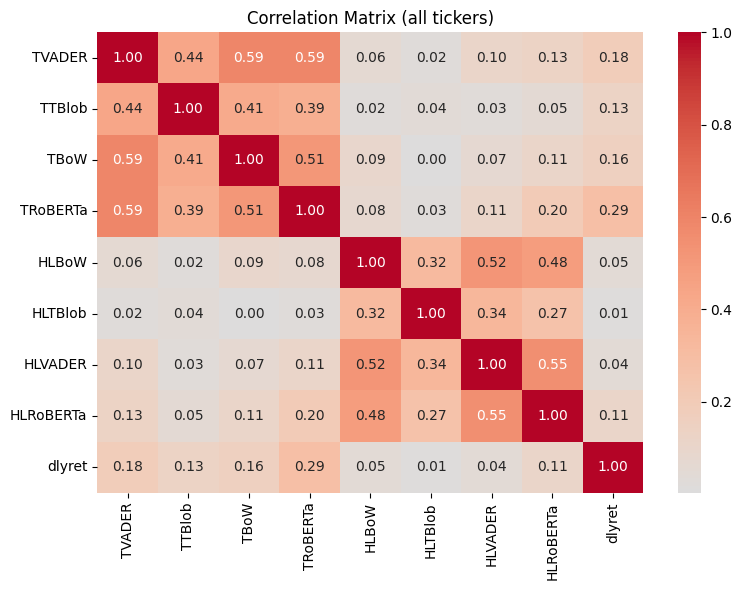

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ["TVADER", "TTBlob", "TBoW", "TRoBERTa", "HLBoW", "HLTBlob", "HLVADER", "HLRoBERTa", "dlyret"]

# Overall
corr_sum = None
for ticker in tickers:
    corr = dfs[ticker][cols].corr()
    if corr_sum is None:
        corr_sum = corr
    else:
        corr_sum += corr

corr_mean = corr_sum / len(tickers)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_mean, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix (all tickers)')
plt.tight_layout()
plt.show()

Ici, il faut utiliser le sentiment qu'on a déjà averagé.

In [21]:
df = pd.read_csv("data/output/finBERT_sentiment.csv")
df['date'] = pd.to_datetime(df['post_date'], unit='s').dt.date

# Mapping: positive = +1, negative = -1, neutral = 0
sentiment_map = {'positive': 1, 'negative': -1, 'neutral': 0}
df['sentiment_value'] = df['finBERT_label'].map(sentiment_map)

# Daily global sentiment
daily_global = (df.groupby('date')['sentiment_value'].mean().reset_index(name='sentiment_score'))
daily_global['date'] = pd.to_datetime(daily_global['date'])

# Daily firm sentiment
df_exploded = df.copy()
df_exploded['ticker'] = df_exploded['ticker'].str.split(', ')
df_exploded = df_exploded.explode('ticker')
df_exploded['ticker'] = df_exploded['ticker'].str.strip()

daily_per_firm = (
    df_exploded.groupby(['date', 'ticker'])['sentiment_value']
    .mean()
    .reset_index(name='sentiment_score')
)
daily_per_firm['date'] = pd.to_datetime(daily_per_firm['date'])

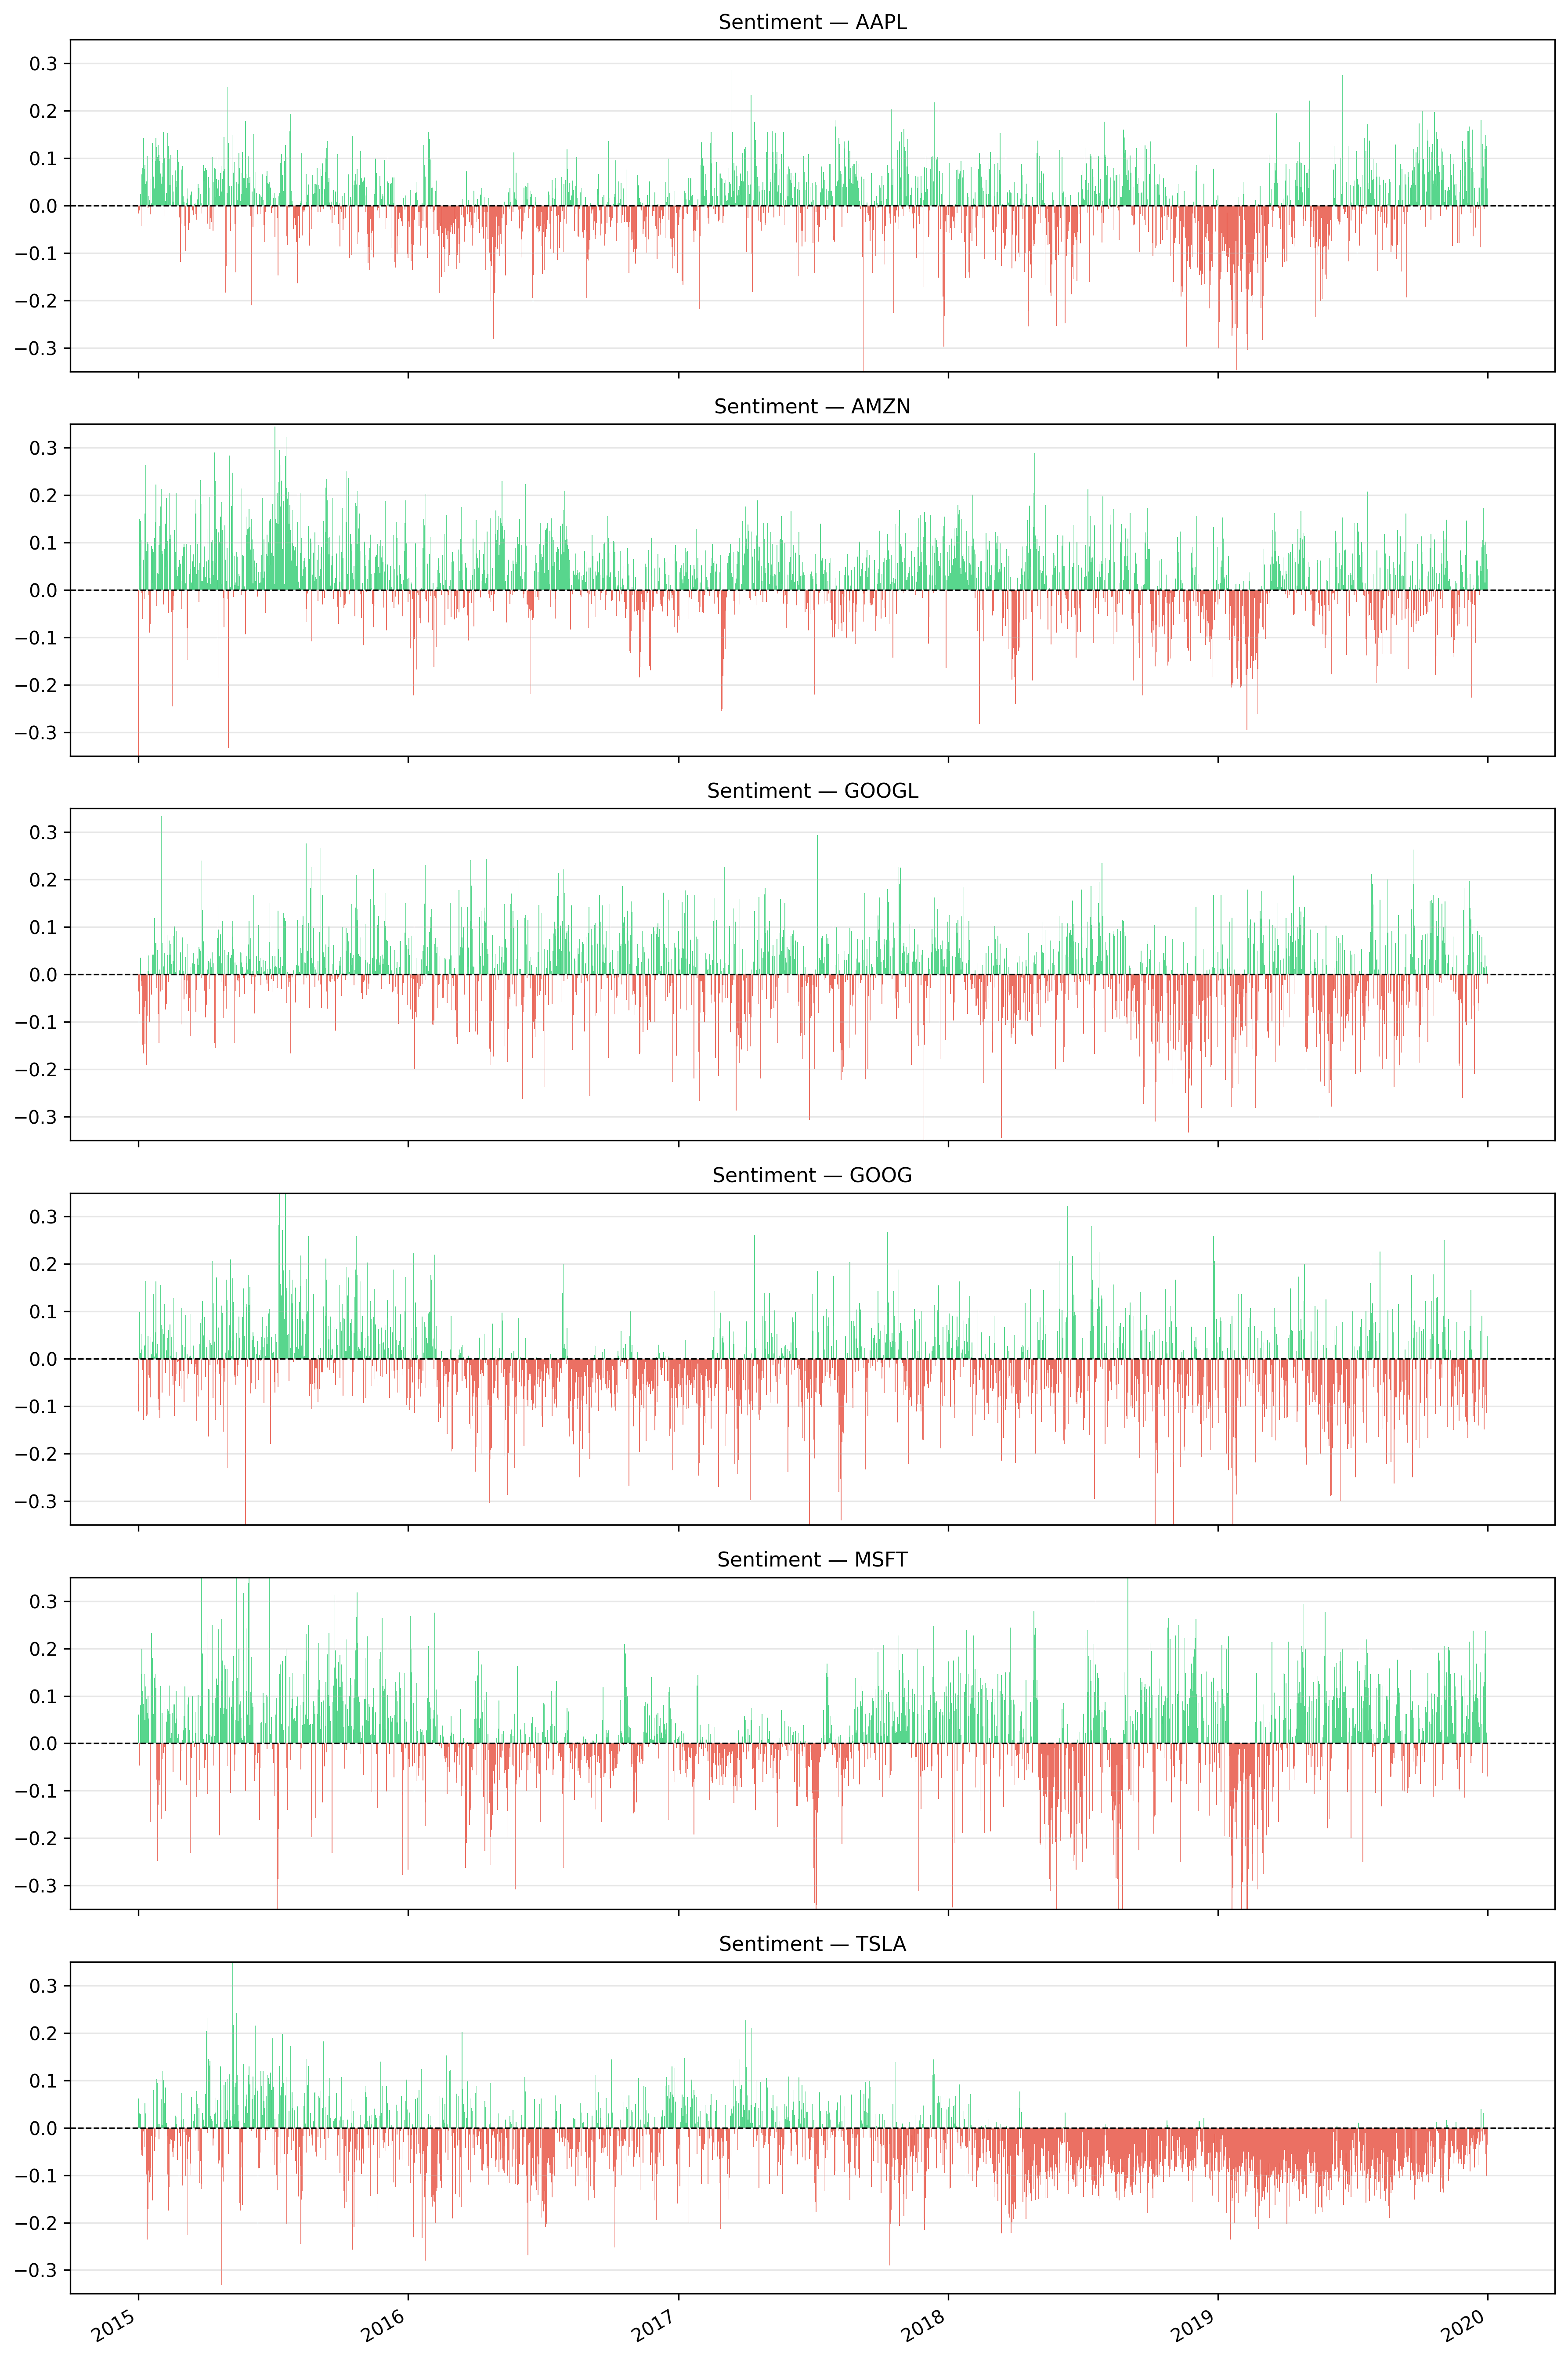

In [33]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

firms = ['AAPL', 'AMZN', 'GOOGL', 'GOOG', 'MSFT', 'TSLA'] 

n_plots = len(firms)
fig, axes = plt.subplots(n_plots, 1, figsize=(12, 3 * n_plots), sharex=True, dpi=300)

all_data = [(f"Sentiment — {f}", daily_per_firm[daily_per_firm['ticker'] == f].sort_values('date')) for f in firms]

for ax, (title, data) in zip(axes, all_data):
    colors = ['#e74c3c' if s < 0 else '#2ecc71' for s in data['sentiment_score']]

    ax.bar(data['date'], data['sentiment_score'], color=colors, width=1, alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

    ax.set_title(title, fontsize=11)
    ax.set_ylim(-0.35, 0.35)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.grid(axis='y', alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()